# 🧠 NutriSense - Nutrition Risk Prediction Model

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 📊 Load Dataset

In [119]:
df = pd.read_csv("data/final_nutrition_dataset_balanced.csv")

In [120]:
df.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),Unnamed: 12,nutrition_risk,Disease,Portion_Size_g,Meal_ID,Day_Type,Log_Index,Confidence_Level
0,Manicotti (2 shells cheese),Meal/Pasta,380,20.739158,35.167759,18.428677,3.986625,7.176264,633.419795,58.756822,Dinner,0,NaN,Unhealthy,"Hypertension, Obesity",200,178,Weekend,1619,Medium
1,Tuna Sauce (2 tbsp),Condiment,100,4.105962,1.015272,8.830426,0.000000,0.515085,193.635879,14.933727,Lunch,0,NaN,Healthy,Healthy,250,158,Weekday,2542,High
2,Vitello Tonnato (1 serving),Meal/Meat,380,36.296747,2.877859,25.255635,0.500300,1.026956,609.421971,105.255864,Lunch,0,NaN,Unhealthy,"Hypertension, Obesity, Heart Disease",180,161,Weekday,3456,Medium
3,Tuna Melt,Meal/Processed,450,24.957741,32.002888,25.082233,3.136074,3.983427,923.167369,48.913468,Lunch,250,NaN,Unhealthy,"Hypertension, Obesity, Heart Disease",100,101,Weekend,7470,Medium
4,Ice Cream (1/2 cup vanilla),Dairy/Dessert,145,2.564908,17.387051,7.872721,0.487351,16.461352,57.653859,29.306213,Snack,0,NaN,Moderate,Diabetes,100,95,Weekend,3853,High


In [121]:
print("Before:", df.shape)

Before: (19626, 20)


## 🧹 Data Cleaning

In [122]:
df = df.drop(columns=[
    "Unnamed: 12",
    "Meal_ID",
    "Log_Index",
    "Confidence_Level"
], errors="ignore")

In [123]:
print("after:", df.shape)

after: (19626, 16)


In [124]:
df.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),nutrition_risk,Disease,Portion_Size_g,Day_Type
0,Manicotti (2 shells cheese),Meal/Pasta,380,20.739158,35.167759,18.428677,3.986625,7.176264,633.419795,58.756822,Dinner,0,Unhealthy,"Hypertension, Obesity",200,Weekend
1,Tuna Sauce (2 tbsp),Condiment,100,4.105962,1.015272,8.830426,0.000000,0.515085,193.635879,14.933727,Lunch,0,Healthy,Healthy,250,Weekday
2,Vitello Tonnato (1 serving),Meal/Meat,380,36.296747,2.877859,25.255635,0.500300,1.026956,609.421971,105.255864,Lunch,0,Unhealthy,"Hypertension, Obesity, Heart Disease",180,Weekday
3,Tuna Melt,Meal/Processed,450,24.957741,32.002888,25.082233,3.136074,3.983427,923.167369,48.913468,Lunch,250,Unhealthy,"Hypertension, Obesity, Heart Disease",100,Weekend
4,Ice Cream (1/2 cup vanilla),Dairy/Dessert,145,2.564908,17.387051,7.872721,0.487351,16.461352,57.653859,29.306213,Snack,0,Moderate,Diabetes,100,Weekend


In [125]:
print(df["nutrition_risk"].value_counts())

nutrition_risk
Unhealthy    6542
Healthy      6542
Moderate     6542
Name: count, dtype: int64


## 🔍 Exploratory Data Analysis (EDA)

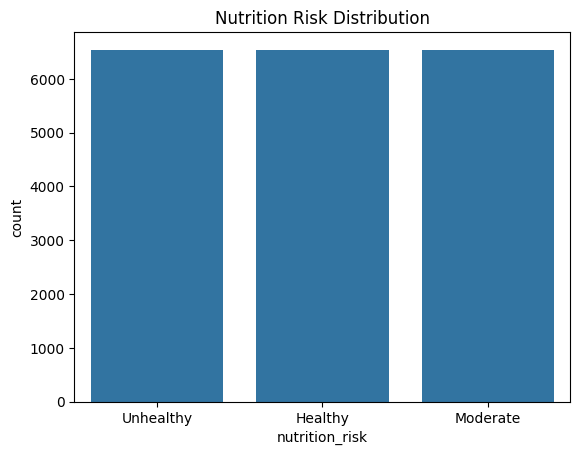

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="nutrition_risk", data=df)
plt.title("Nutrition Risk Distribution")
plt.show()

In [127]:
df.describe()

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Portion_Size_g
count,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000
mean,256.098899,11.539899,23.719966,12.744978,2.154193,7.668000,439.342129,41.095107,176.467951
std,182.230948,13.678019,18.352951,11.185939,1.935414,9.752359,380.026371,60.085423,50.664254
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000
25%,97.000000,1.655246,4.834814,1.187857,0.482395,1.017687,62.518757,0.000000,150.000000
50%,220.000000,6.572627,25.000000,11.122143,2.018084,3.938070,363.667687,20.119641,180.000000
75%,400.000000,19.296950,36.472699,21.612116,3.070985,9.353487,765.605637,61.535349,200.000000
max,680.000000,206.512683,73.187593,41.969257,14.621514,61.469069,1650.136180,466.181073,250.000000


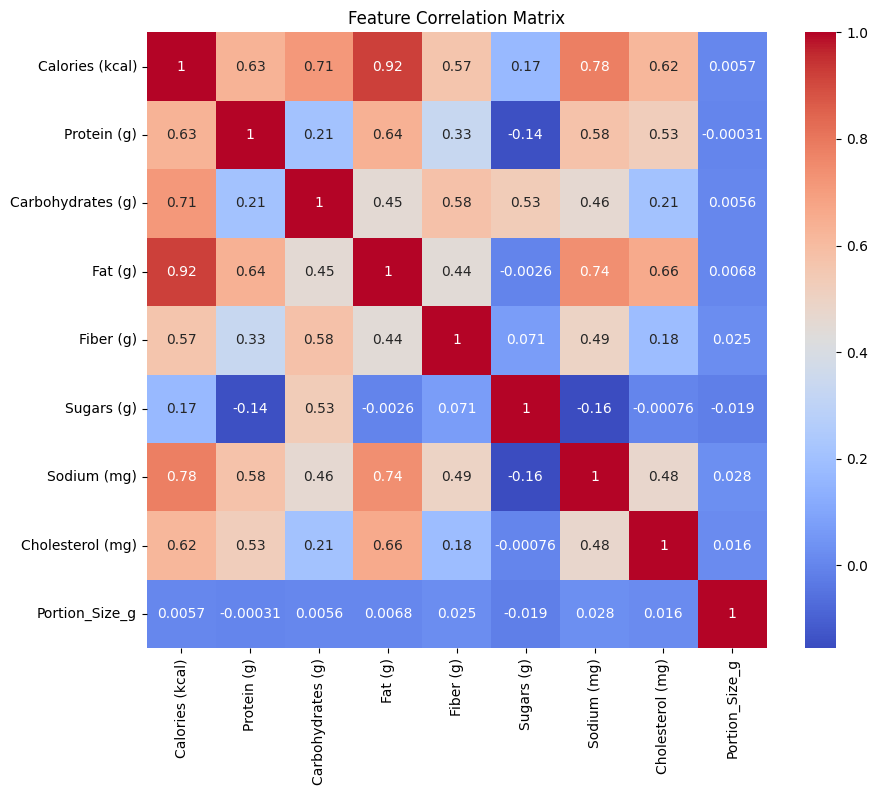

In [128]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

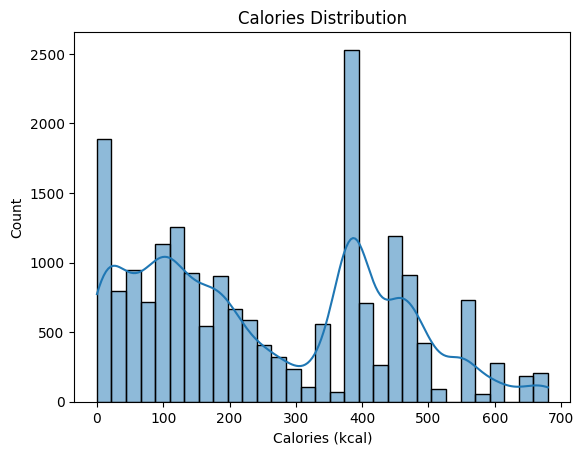

In [129]:
sns.histplot(df["Calories (kcal)"], kde=True)
plt.title("Calories Distribution")
plt.show()

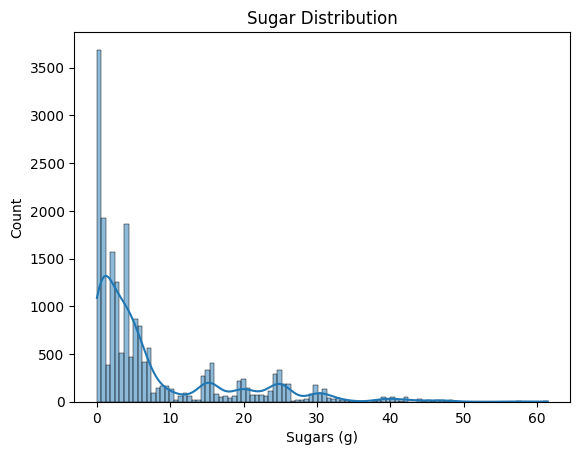

In [130]:
sns.histplot(df["Sugars (g)"], kde=True)
plt.title("Sugar Distribution")
plt.show()

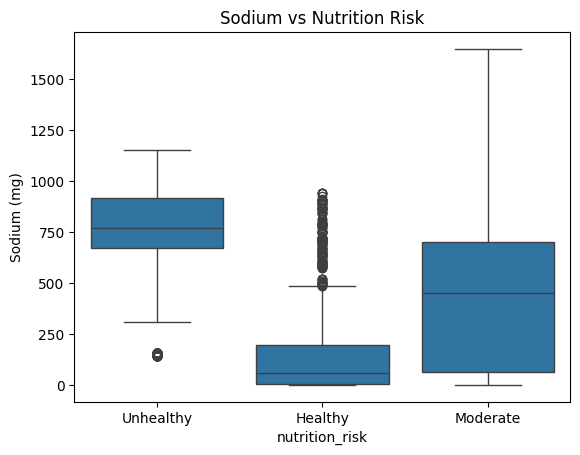

In [131]:
sns.boxplot(x="nutrition_risk", y="Sodium (mg)", data=df)
plt.title("Sodium vs Nutrition Risk")
plt.show()

In [132]:
X = df.drop("nutrition_risk", axis=1)
print(X.columns)
print(X.dtypes)

Index(['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)',
       'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)',
       'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)',
       'Disease', 'Portion_Size_g', 'Day_Type'],
      dtype='object')
Food_Item             object
Category              object
Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Fiber (g)            float64
Sugars (g)           float64
Sodium (mg)          float64
Cholesterol (mg)     float64
Meal_Type             object
Water_Intake (ml)     object
Disease               object
Portion_Size_g         int64
Day_Type              object
dtype: object


## ⚙️ Feature Selection

In [133]:
X = df[['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 
        'Fat (g)', 'Sugars (g)']]

y = df['nutrition_risk']

In [134]:
print(X.dtypes)

Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Sugars (g)           float64
dtype: object


## ✂️ Train-Test Split

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 🔤 Label Encoding

In [138]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Healthy' 'Moderate' 'Unhealthy']


In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 🤖 Model Training

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_scaled, y_encoded)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_scaled, y_encoded)

# Random Forest
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    random_state=42
)
rf.fit(X_scaled, y_encoded)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## 📊 Model Accuracy Evaluation

In [142]:
from sklearn.metrics import accuracy_score

# Predictions
lr_pred = lr.predict(X_scaled)
dt_pred = dt.predict(X_scaled)
rf_pred = rf.predict(X_scaled)

# Accuracy
lr_acc = accuracy_score(y_encoded, lr_pred)
dt_acc = accuracy_score(y_encoded, dt_pred)
rf_acc = accuracy_score(y_encoded, rf_pred)

print("Logistic Regression:", lr_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.8264037501273821
Decision Tree: 0.9962294914908795
Random Forest: 0.9962294914908795


## 📊 Model Accuracy Evaluation

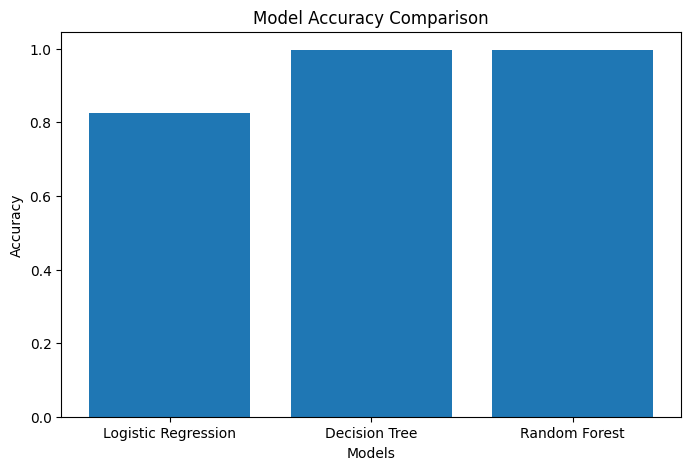

In [143]:
import matplotlib.pyplot as plt

model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

## 🏆 Model Selection

In [144]:
best_model = rf  # Random Forest is best

print("Selected Model: Random Forest")

Selected Model: Random Forest


## 📉 ROC Curve Analysis

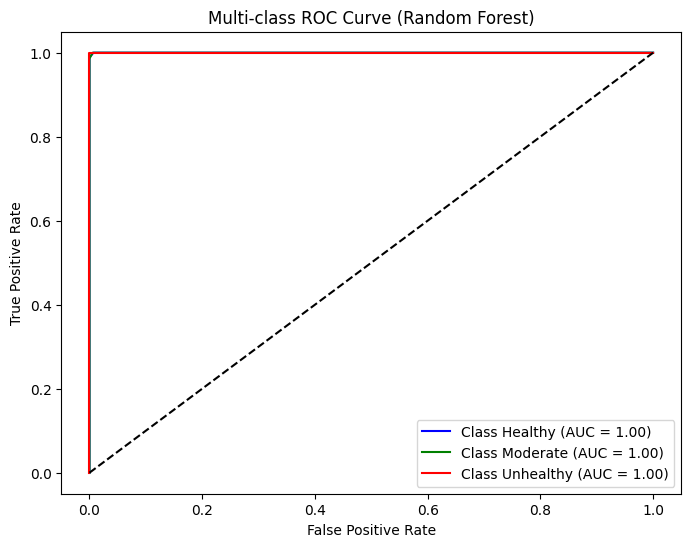

In [145]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Number of classes
classes = [0, 1, 2]

# Binarize target
y_bin = label_binarize(y_encoded, classes=classes)

# Predict probabilities
y_prob = model.predict_proba(X_scaled)

# Colors for each class
colors = ['blue', 'green', 'red']
labels = ['Healthy', 'Moderate', 'Unhealthy']

plt.figure(figsize=(8,6))

# Plot ROC curve for each class
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        color=colors[i],
        label=f'Class {labels[i]} (AUC = {roc_auc:.2f})'
    )

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--')

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (Random Forest)")

# Legend
plt.legend(loc="lower right")

plt.show()

## 📊 Confusion Matrix (Random Forest)

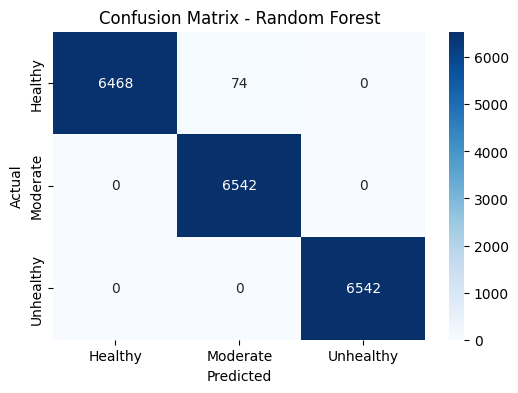

In [146]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = rf.predict(X_scaled)

# Confusion matrix
cm = confusion_matrix(y_encoded, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 📊 Feature Importance Analysis

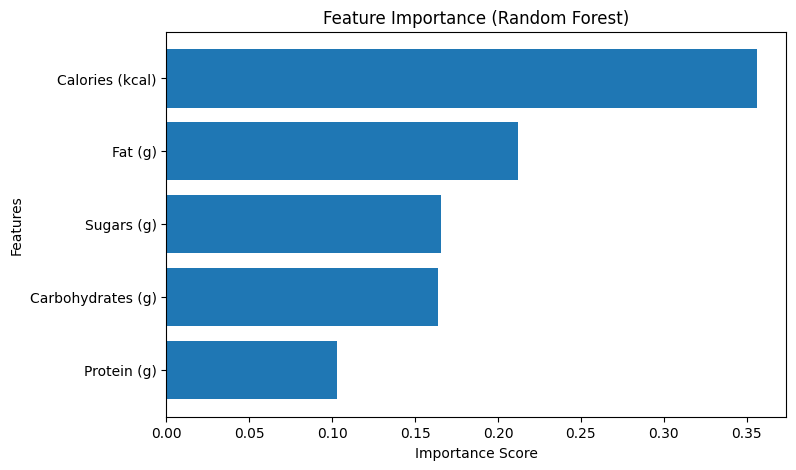

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from model
importances = model.feature_importances_

# Feature names (same order as your dataset)
feature_names = [
    "Calories (kcal)",
    "Protein (g)",
    "Carbohydrates (g)",
    "Fat (g)",
    "Sugars (g)"
]

# Create DataFrame
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort values (ascending for horizontal bar)
feat_df = feat_df.sort_values(by="Importance", ascending=True)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_df["Feature"], feat_df["Importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## 💾 Save Model

In [148]:
import joblib

joblib.dump(best_model, "model/nutrition_risk_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")
joblib.dump(label_encoder, "model/label_encoder.pkl")

['model/label_encoder.pkl']

In [149]:
import joblib

joblib.dump(rf, "model/nutrition_risk_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

## 🔮 Sample Prediction

In [150]:
sample = [[450, 25, 32, 25, 4]]  # like Tuna Melt
sample_scaled = scaler.transform(sample)

pred = model.predict(sample_scaled)
print(label_encoder.inverse_transform(pred))

['Unhealthy']


C:\Users\Hima Bindu\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [151]:
import pandas as pd

sample = pd.DataFrame([[450, 25, 32, 25, 4]],
                      columns=['Calories (kcal)', 'Protein (g)', 
                               'Carbohydrates (g)', 'Fat (g)', 'Sugars (g)'])

sample_scaled = scaler.transform(sample)
pred = model.predict(sample_scaled)

print(label_encoder.inverse_transform(pred))

['Unhealthy']


In [152]:
print("MODEL RAW OUTPUT:", model.predict(X_scaled))

MODEL RAW OUTPUT: [2 0 2 ... 0 0 2]


In [153]:
ml_risk_encoded = model.predict(X_scaled)[0]

In [154]:
print("Encoded:", ml_risk_encoded)

Encoded: 2
